In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score
print("all set to go...")


all set to go...


In [75]:
df= pd.read_csv("StudentsPerformance.csv")
df.columns= df.columns.str.lower().str.replace(" ","_")
df.sample(10)

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
237,female,group D,some high school,standard,completed,64,60,74
803,female,group B,some college,standard,none,82,85,87
322,female,group C,some college,standard,none,71,81,80
425,female,group C,some college,free/reduced,none,62,67,62
683,female,group C,some high school,free/reduced,completed,29,40,44
50,male,group E,some college,standard,none,53,55,48
290,male,group C,associate's degree,standard,none,76,70,68
75,male,group B,associate's degree,free/reduced,none,44,41,38
741,female,group A,associate's degree,free/reduced,none,37,57,56
655,female,group B,some college,standard,none,62,67,67


In [76]:
df['parental_level_of_education'].unique()

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [78]:
df.shape

(1000, 8)

In [79]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [80]:
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [81]:
for data_val in df.columns:
  print(df[data_val].value_counts())
  print("****"*5)

gender
female    518
male      482
Name: count, dtype: int64
********************
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
********************
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
********************
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
********************
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
********************
math_score
65    36
62    35
69    32
59    32
73    27
      ..
24     1
26     1
19     1
23     1
8      1
Name: count, Length: 81, dtype: int64
********************
reading_score
72    34
74    33
64    32
73    30
67    30
      ..
17     1
26     1
28     1
23     1
40     1
Name: count, Length: 72, dtype: int64
********************
writing_sco

In [82]:
df.rename(columns=
          {"race/ethnicity":"race"},
          inplace=True)

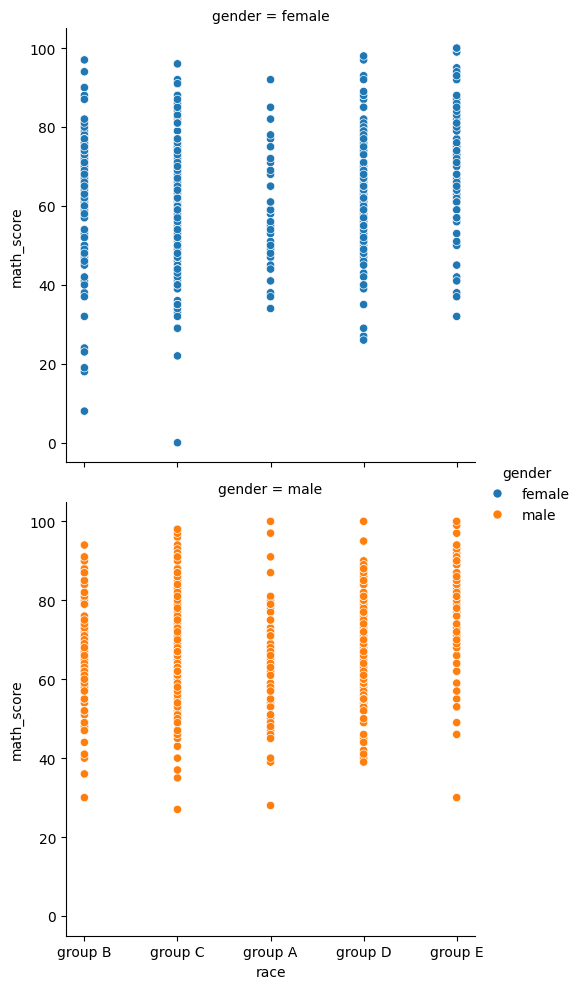

In [83]:
sns.relplot(data=df,x="race",y="math_score",hue="gender",kind="scatter",row="gender")
plt.show()

<Axes: >

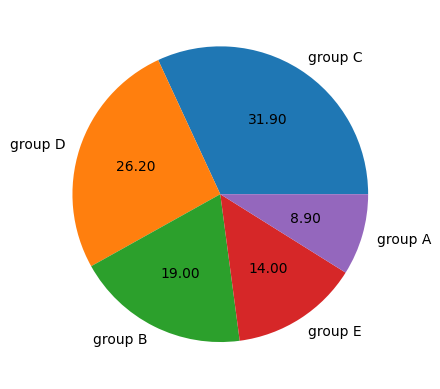

In [84]:
df["race"].value_counts().plot(kind='pie',autopct="%.2f")

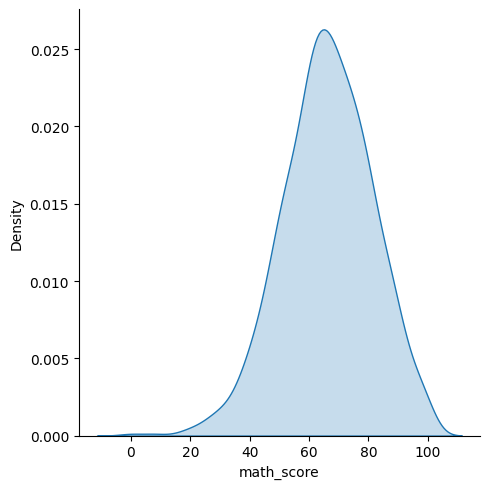

In [85]:
sns.displot(data=df, x="math_score",kind="kde",fill=True)

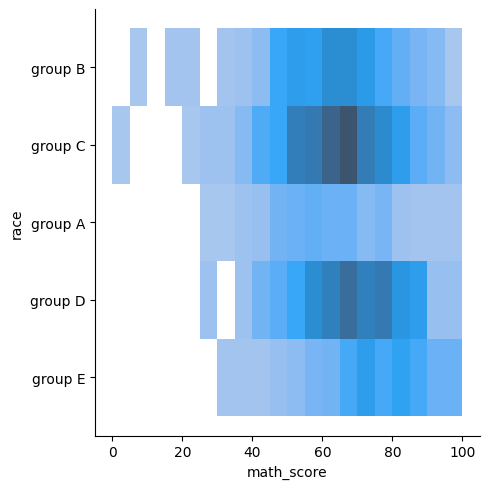

In [86]:
sns.displot(data=df,x="math_score",y="race",kind="hist",bins=20)

<Axes: xlabel='gender', ylabel='math_score'>

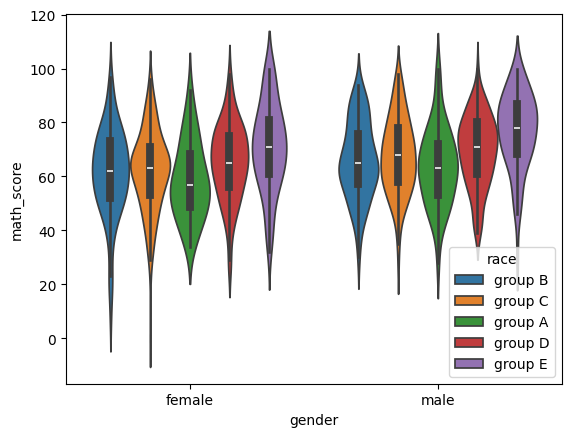

In [87]:
sns.violinplot(data=df, x='gender', y='math_score', hue='race', split=False)

In [88]:
df


,gender,race,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


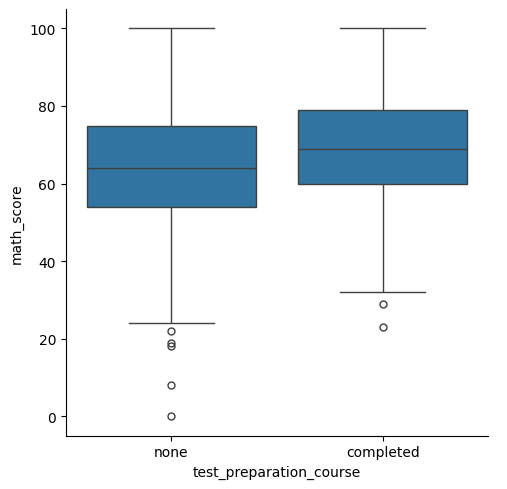

In [89]:
sns.catplot(data=df,x="test_preparation_course",y='math_score',kind='box')


In [90]:
df.sample(5)

,gender,race,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
99,female,group D,bachelor's degree,standard,none,65,67,62
232,female,group B,bachelor's degree,standard,none,67,86,83
798,male,group E,some college,standard,none,69,60,54
267,female,group D,high school,standard,none,69,72,77
945,female,group C,associate's degree,standard,none,54,61,58


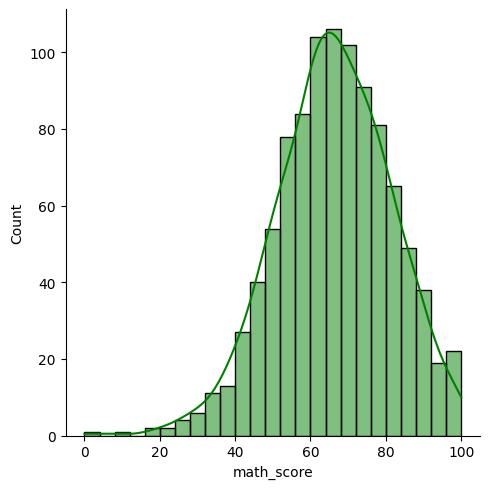

In [91]:
sns.displot(data=df, x="math_score",kde=True,kind='hist',color='green')

In [92]:
upper_limit = df['math_score'].mean()+3*df['math_score'].std()
lower_limit = df['math_score'].mean()-3*df['math_score'].std()
print(upper_limit)
print(lower_limit)

111.57824028802835
20.59975971197165


In [93]:
df[(df['math_score']>111.57824028802841) | (df['math_score']<20.599759711971593)]

,gender,race,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
787,female,group B,some college,standard,none,19,38,32
980,female,group B,high school,free/reduced,none,8,24,23


In [94]:
df["math_score_z"]=(df['math_score']-df['math_score'].mean())/df["math_score"].std()
new_df= df[(df['math_score_z']<=3)& (df['math_score_z']>=-3)]
new_df

,gender,race,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,math_score_z
0,female,group B,bachelor's degree,standard,none,72,72,74,0.389828
1,female,group C,some college,standard,completed,69,90,88,0.191979
2,female,group B,master's degree,standard,none,90,95,93,1.576922
3,male,group A,associate's degree,free/reduced,none,47,57,44,-1.258913
4,male,group C,some college,standard,none,76,78,75,0.653627
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,1.445023
996,male,group C,high school,free/reduced,none,62,55,55,-0.269668
997,female,group C,high school,free/reduced,completed,59,71,65,-0.467517
998,female,group D,some college,standard,completed,68,78,77,0.126030


In [95]:
df['math_score'] = np.where(df['math_score']>upper_limit,upper_limit,
                            np.where(df['math_score']<lower_limit,lower_limit,df['math_score']))
df

,gender,race,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,math_score_z
0,female,group B,bachelor's degree,standard,none,72.0,72,74,0.389828
1,female,group C,some college,standard,completed,69.0,90,88,0.191979
2,female,group B,master's degree,standard,none,90.0,95,93,1.576922
3,male,group A,associate's degree,free/reduced,none,47.0,57,44,-1.258913
4,male,group C,some college,standard,none,76.0,78,75,0.653627
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88.0,99,95,1.445023
996,male,group C,high school,free/reduced,none,62.0,55,55,-0.269668
997,female,group C,high school,free/reduced,completed,59.0,71,65,-0.467517
998,female,group D,some college,standard,completed,68.0,78,77,0.126030


In [96]:
def remove_outliers(dataframe,columns,threshold=3):
  df_copy=dataframe.copy()
  for cols in columns:
    mean = df_copy[cols].mean()
    std = df_copy[cols].std()

    z_score = f"{cols}_z"
    df_copy[z_score] = (df_copy[cols]-mean)/std

    df_copy = df_copy[(df_copy[z_score]<=threshold)& (df_copy[z_score]>=-threshold)]
    df_copy = df_copy.drop(columns=[z_score])


  return df_copy

In [97]:
col_remove = ['math_score','writing_score','reading_score']
new_df = remove_outliers(df,columns=col_remove)
new_df

,gender,race,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72.0,72,74
1,female,group C,some college,standard,completed,69.0,90,88
2,female,group B,master's degree,standard,none,90.0,95,93
3,male,group A,associate's degree,free/reduced,none,47.0,57,44
4,male,group C,some college,standard,none,76.0,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88.0,99,95
996,male,group C,high school,free/reduced,none,62.0,55,55
997,female,group C,high school,free/reduced,completed,59.0,71,65
998,female,group D,some college,standard,completed,68.0,78,77


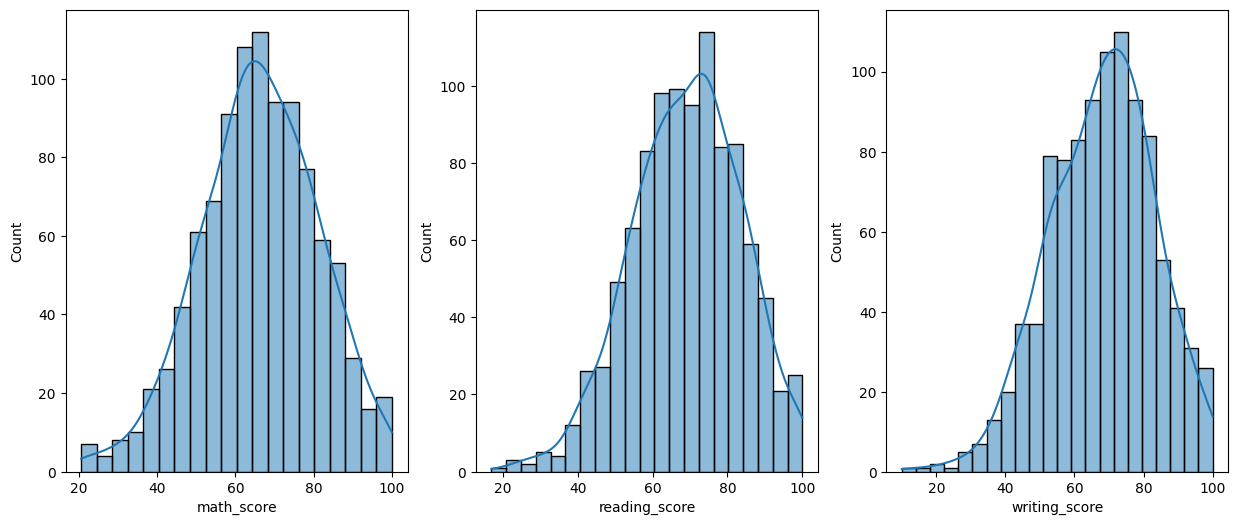

In [98]:
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
sns.histplot(data=df, x="math_score",kde=True,)

plt.subplot(1,3,2)
sns.histplot(data=df, x="reading_score",kde=True)

plt.subplot(1,3,3)
sns.histplot(data=df, x="writing_score",kde=True)
plt.show()

In [99]:
x_train,x_test,y_train,y_test =train_test_split(df.drop(columns=['math_score','math_score_z']),df['math_score'],test_size=0.2,random_state=2)

In [100]:
x_train

,gender,race,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
175,female,group C,master's degree,standard,completed,91,87
818,female,group B,high school,free/reduced,none,72,68
677,female,group C,some high school,standard,completed,82,76
952,female,group E,some high school,free/reduced,none,74,72
200,female,group C,associate's degree,standard,completed,84,86
...,...,...,...,...,...,...,...
534,male,group B,high school,standard,completed,69,68
584,female,group D,some college,standard,none,77,77
493,female,group C,bachelor's degree,standard,none,88,90
527,female,group C,high school,free/reduced,none,53,43


In [101]:
scaler = StandardScaler()
trf = ColumnTransformer([
    ("scaler",scaler,['reading_score','writing_score'])]
    ,remainder='passthrough',verbose_feature_names_out=False)
trf.set_output(transform='pandas')
x_train_trf=trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [102]:
x_train_trf

,reading_score,writing_score,gender,race,parental_level_of_education,lunch,test_preparation_course
175,1.482843,1.247697,female,group C,master's degree,standard,completed
818,0.180676,-0.006104,female,group B,high school,free/reduced,none
677,0.866027,0.521812,female,group C,some high school,standard,completed
952,0.317746,0.257854,female,group E,some high school,free/reduced,none
200,1.003097,1.181707,female,group C,associate's degree,standard,completed
...,...,...,...,...,...,...,...
534,-0.024930,-0.006104,male,group B,high school,standard,completed
584,0.523351,0.587802,female,group D,some college,standard,none
493,1.277238,1.445665,female,group C,bachelor's degree,standard,none
527,-1.121492,-1.655842,female,group C,high school,free/reduced,none


In [103]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
trf2 = ColumnTransformer([
    ("ohe",ohe,['gender','race','parental_level_of_education',"test_preparation_course","lunch"])]
    ,remainder="passthrough",verbose_feature_names_out=False
)
trf2.set_output(transform="pandas")
x_train_trf=trf2.fit_transform(x_train_trf)
x_test_trf=trf2.transform(x_test_trf)

In [104]:
x_train_trf

,gender_female,gender_male,race_group A,race_group B,race_group C,race_group D,race_group E,parental_level_of_education_associate's degree,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,test_preparation_course_completed,test_preparation_course_none,lunch_free/reduced,lunch_standard,reading_score,writing_score
175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.482843,1.247697
818,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.180676,-0.006104
677,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.866027,0.521812
952,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.317746,0.257854
200,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.003097,1.181707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.024930,-0.006104
584,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.523351,0.587802
493,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.277238,1.445665
527,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.121492,-1.655842


In [105]:
models ={
 "LinearRegression": LinearRegression(),
"Decision Tree": DecisionTreeRegressor(random_state=42),
"Random Forest": RandomForestRegressor(random_state=42),
"KNN": KNeighborsRegressor(),
"SVR": SVR()
}

In [106]:
for name, model in models.items():
  model.fit(x_train_trf,y_train)
  y_pred = model.predict(x_test_trf)
  score= r2_score(y_test,y_pred)
  print(f"{name}: {score:.4f}")

LinearRegression: 0.8534
Decision Tree: 0.7048
Random Forest: 0.8149
KNN: 0.7325
SVR: 0.7710
